# Vote concentration and population density by département — 2002 & 2022

**Question:** is the geographic variation in the concentration of the first-round vote (2002 and 2022 presidential
elections) associated with population density?

Reads `data/processed/coordination_density_departements.csv` and `..._wide.csv` (built by `scripts/01`–`04`).
Main sample: the 96 metropolitan départements. Everything here is **descriptive**: correlations and OLS slopes
summarise associations across départements; they are not causal effects of urbanisation.

**Measures** (definitions in `svgeo/indices.py`):

* **HHI** $=\sum_j s_j^2$, the observed concentration of the vote (higher = more concentrated). It is the **main
  measure for comparing 2002 and 2022**: an unchanged vote vector has an unchanged HHI whatever the number of
  candidates, and a candidate with no vote does not change it.
* **ENP** $= 1/\text{HHI}$, the effective number of candidates, for interpretation.
* **CENP** $= (K-\text{ENP})/(K-1)$, a supplementary normalised measure, kept for continuity with the ABM. It depends
  directly on $K$ (16 candidates in 2002, 12 in 2022), so rescaling to $[0, 1]$ does not make the two elections fully
  comparable. Within one election $K$ is fixed and CENP orders départements exactly as HHI does.

A change in HHI can reflect candidate supply, preferences, campaigns or strategic voting: none of these measures
identifies strategic voting or proves coordination on its own.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

from svgeo.analysis import association_stats, department_scatter, pooled_interaction, show_plot
from svgeo.config import DEPARTMENT_DENSITY, DEPARTMENT_DENSITY_WIDE, DEPARTMENT_RESULTS, METRO_CODES, YEARS
from svgeo.utils import read_csv

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

merged = read_csv(DEPARTMENT_DENSITY)
main = merged[merged["in_main_sample"]].copy()
wide = read_csv(DEPARTMENT_DENSITY_WIDE)
main.groupby("year").size()

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


year
2002    96
2022    96
dtype: int64

## 1. Descriptive statistics

The means below are **unweighted means across départements**: they describe the typical département, each counting
once whatever its size. They are not the national concentration level, which is computed further down from the
candidates' votes aggregated over the whole country.

In [2]:
main.groupby("year").agg(
    n=("department_code", "size"),
    HHI_mean=("HHI", "mean"), HHI_median=("HHI", "median"), HHI_sd=("HHI", "std"),
    ENP_mean=("ENP", "mean"),
    CENP_mean=("CENP", "mean"), CENP_median=("CENP", "median"), CENP_sd=("CENP", "std"),
    density_mean=("density", "mean"), density_median=("density", "median"),
    log_density_mean=("log_density", "mean"),
)

,n,HHI_mean,HHI_median,HHI_sd,ENP_mean,CENP_mean,CENP_median,CENP_sd,density_mean,density_median,log_density_mean
year,,,,,,,,,,,
2002,96,0.119960,0.117657,0.010301,8.390653,0.507290,0.500046,0.043391,529.260736,78.610564,4.586577
2022,96,0.195654,0.194263,0.019894,5.158063,0.621994,0.622931,0.043344,566.654391,83.420990,4.666628


### National concentration

HHI of the vote shares obtained by summing each candidate's votes over (a) the 96 metropolitan départements and (b)
every territory in the département-level results (overseas and French voters abroad included). This is the
concentration of the national result, which differs from the unweighted mean across départements above.

In [3]:
results = read_csv(DEPARTMENT_RESULTS)
results = results[results["dep_name"].notna()]  # 2022: drop the unnamed duplicate of Saint-Martin/Saint-Barthélemy


def national_concentration(res):
    votes = res.groupby(["year", "candidate_clean"])["votes"].sum()
    hhi = ((votes / votes.groupby(level="year").transform("sum")) ** 2).groupby(level="year").sum()
    return pd.DataFrame({"HHI": hhi, "ENP": 1 / hhi})


national = pd.concat({
    "national, metropolitan départements": national_concentration(results[results["dep_code"].isin(METRO_CODES)]),
    "national, all territories": national_concentration(results),
    "unweighted mean across départements": main.groupby("year")[["HHI", "ENP"]].mean(),
}, axis=1)
national.T.round(4)

year                                       2002    2022
national, metropolitan départements HHI  0.1143  0.1904
                                    ENP  8.7499  5.2528
national, all territories           HHI  0.1154  0.1911
                                    ENP  8.6650  5.2331
unweighted mean across départements HHI  0.1200  0.1957
                                    ENP  8.3907  5.1581

### Density quartiles (within each election year)

Descriptive groupings, not causal categories.

In [4]:
QUARTILE_LABELS = ["Q1 (least dense)", "Q2", "Q3", "Q4 (most dense)"]
main["density_quartile"] = main.groupby("year")["density"].transform(
    lambda s: pd.qcut(s, 4, labels=QUARTILE_LABELS).astype(str))

main.groupby(["year", "density_quartile"]).agg(
    n_departements=("department_code", "size"),
    density_min=("density", "min"), density_max=("density", "max"),
    HHI_mean=("HHI", "mean"), HHI_median=("HHI", "median"),
    CENP_mean=("CENP", "mean"), CENP_median=("CENP", "median"),
    cliff_magnitude_mean=("cliff_magnitude", "mean"), cliff_ratio_mean=("cliff_ratio", "mean"),
)

n_departements  density_min   density_max  HHI_mean  HHI_median  CENP_mean  CENP_median  cliff_magnitude_mean  cliff_ratio_mean
year density_quartile                                                                                                                                 
2002 Q1 (least dense)              24    14.487853     48.017328  0.123854    0.121363   0.520602     0.517348              0.080521          0.876329
     Q2                            24    49.202386     76.793489  0.117428    0.117319   0.497199     0.498416              0.074589          0.888562
     Q3                            24    80.427639    149.898582  0.117516    0.116747   0.498365     0.495632              0.073941          0.879079
     Q4 (most dense)               24   151.273163  20355.521822  0.121044    0.118594   0.512993     0.504511              0.079747          0.892690
2022 Q1 (least dense)              24    14.806421     46.353515  0.182994    0.178399   0.590435     0.581311              0.113056          0.872607
     Q2                            24    51.096395     83.364284  0.193678    0.191385   0.618488     0.615892              0.127630          0.885928
     Q3                            24    83.477695    167.907863  0.198519    0.197774   0.631528     0.631228              0.124429          0.873578
     Q4 (most dense)               24   169.027568  20054.127135  0.207425    0.198917   0.647525     0.633888              0.135105          0.878329

## 2. Vote concentration and density in each year

Main outcome: HHI (higher = more concentrated first-round vote). CENP is shown for continuity: within one election it
is a monotone transformation of HHI, so rank correlations are identical and only the scale of the slope differs. The
raw-density plot has no trend line: density is extremely right-skewed (Paris), so a linear fit on the raw scale would
be driven by a handful of départements.

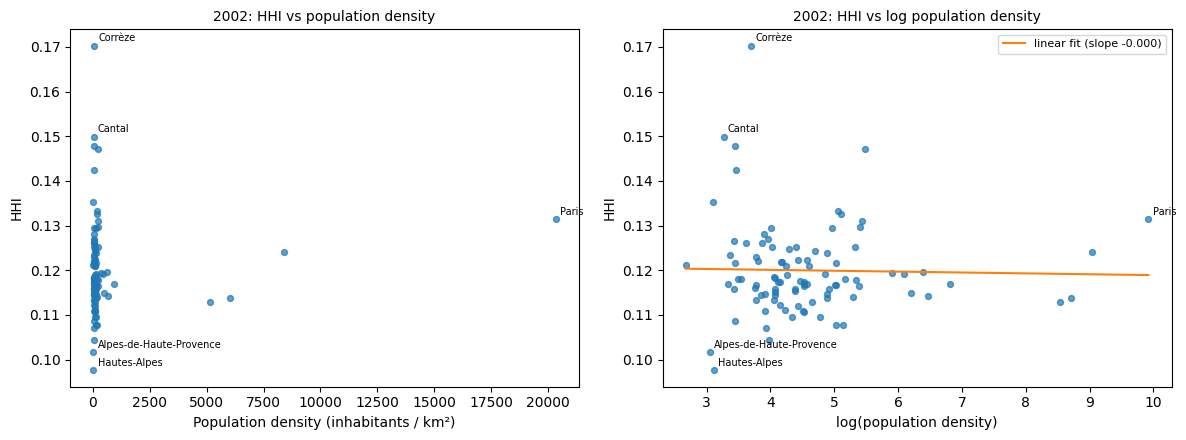

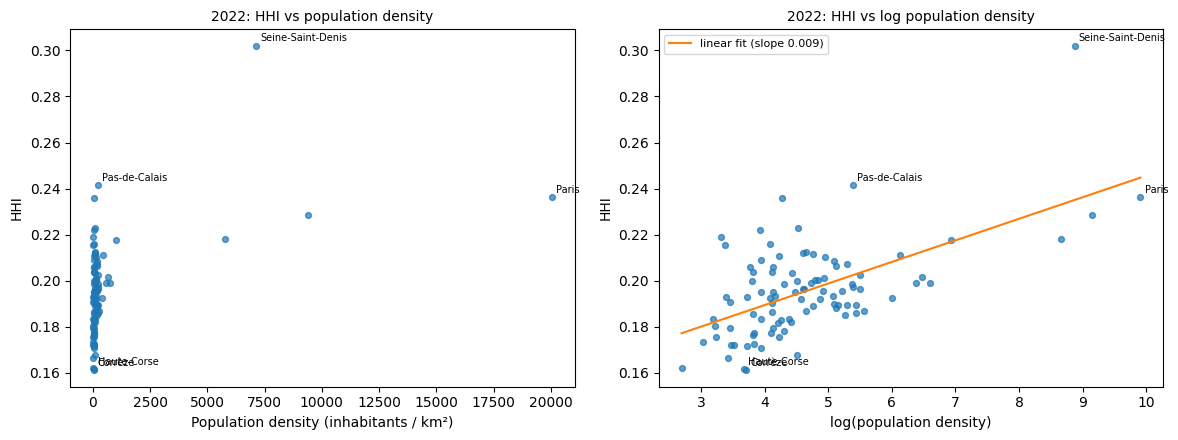

In [5]:
def density_scatters(df, year, y="HHI", ylabel="HHI"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    department_scatter(df, "density", y, axes[0], f"{year}: {ylabel} vs population density",
                       "Population density (inhabitants / km²)", ylabel, trend=False)
    department_scatter(df, "log_density", y, axes[1], f"{year}: {ylabel} vs log population density",
                       "log(population density)", ylabel)
    show_plot(fig)


for year in YEARS:
    density_scatters(main[main["year"] == year], year)

In [6]:
# HHI (main) and CENP (continuity), separately for each year
pd.concat({y: pd.DataFrame({year: association_stats(main[main["year"] == year], y) for year in YEARS})
           for y in ["HHI", "CENP"]}, axis=1)

HHI                     CENP              
                   2002          2022       2002          2022
n             96.000000  9.600000e+01  96.000000  9.600000e+01
pearson_r     -0.023563  5.900161e-01   0.006686  5.724848e-01
pearson_p      0.819741  2.518639e-10   0.948455  1.101295e-09
spearman_rho  -0.033207  4.569045e-01  -0.033207  4.569045e-01
spearman_p     0.748070  2.878042e-06   0.748070  2.878042e-06
ols_coef      -0.000197  9.369958e-03   0.000235  1.980751e-02
ols_se         0.000862  1.322495e-03   0.003632  2.925978e-03
ols_se_HC1     0.000877  2.156503e-03   0.003759  3.335698e-03
ols_p          0.819741  2.518639e-10   0.948455  1.101295e-09
ols_p_HC1      0.822840  3.520133e-05   0.950185  4.820769e-08
ols_R2         0.000555  3.481190e-01   0.000045  3.277389e-01

In [7]:
# Full OLS output (descriptive: HHI ~ log_density; the CENP version is in the table above)
for year in YEARS:
    print(f"===== {year} =====")
    print(smf.ols("HHI ~ log_density", data=main[main["year"] == year]).fit().summary())

===== 2002 =====
                            OLS Regression Results                            
Dep. Variable:                    HHI   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.05222
Date:                Wed, 23 Sep 2026   Prob (F-statistic):              0.820
Time:                        18:17:57   Log-Likelihood:                 303.56
No. Observations:                  96   AIC:                            -603.1
Df Residuals:                      94   BIC:                            -598.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.1209      0.004

### Pooled comparison of the 2002 and 2022 slopes

Stacked cross-sections of the 96 départements in both years:

$$\text{HHI}_{it} = \beta_0 + \beta_1 \log\text{density}_{it} + \beta_2 \mathbb{1}[t=2022] + \beta_3 \log\text{density}_{it}\times\mathbb{1}[t=2022] + \varepsilon_{it}$$

$\beta_3$ = how much the density slope differs in 2022. Standard errors clustered by département (each département
appears once per year); HC1 shown as well. The same model with CENP is kept for continuity; its $\beta_2$ is not
interpretable as a change in concentration because CENP depends on $K$. Descriptive associations only.

In [8]:
TERM = "log_density:C(year)[T.2022]"
pooled_data = main[["HHI", "CENP", "log_density", "year", "department_code"]]
print(pooled_interaction(pooled_data, y="HHI").summary().tables[1])

rows = []
for y in ["HHI", "CENP"]:
    cl, hc1 = pooled_interaction(pooled_data, y=y), pooled_interaction(pooled_data, cov="HC1", y=y)
    rows.append({"outcome": y, "n": int(cl.nobs), "slope_2002": cl.params["log_density"],
                 "slope_2022": cl.params["log_density"] + cl.params[TERM], "difference_2022": cl.params[TERM],
                 "se_cluster": cl.bse[TERM], "p_cluster": cl.pvalues[TERM], "se_HC1": hc1.bse[TERM],
                 "p_HC1": hc1.pvalues[TERM]})
pd.DataFrame(rows).set_index("outcome")

                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.1209      0.005     26.548      0.000       0.112       0.130
C(year)[T.2022]                 0.0311      0.012      2.677      0.007       0.008       0.054
log_density                    -0.0002      0.001     -0.224      0.823      -0.002       0.002
log_density:C(year)[T.2022]     0.0096      0.003      3.787      0.000       0.005       0.015


,n,slope_2002,slope_2022,difference_2022,se_cluster,p_cluster,se_HC1,p_HC1
outcome,,,,,,,,
HHI,192,-0.000197,0.009370,0.009567,0.002526,0.000152,0.002328,0.000040
CENP,192,0.000235,0.019808,0.019572,0.005693,0.000586,0.005026,0.000098


## 3. Changes between 2002 and 2022

Matched wide dataset, one row per metropolitan département:

* `delta_HHI = HHI_2022 − HHI_2002` — **main cross-year comparison**: the change in the observed concentration of the
  first-round vote (positive = more concentrated in 2022). It does not depend on the number of candidates, but it
  still mixes everything that changed between the two elections (candidate supply, preferences, campaigns,
  strategic voting), so it is descriptive and not a coordination *gain*;
* `delta_CENP = CENP_2022 − CENP_2002` — supplementary: CENP depends directly on $K$ (16 vs 12 candidates), so its
  change combines the change in the vote with the change in the normalisation;
* `delta_log_density = log_density_2022 − log_density_2002` — same surface in both years, so ≈ population growth rate.

In [9]:
cols = ["HHI_2002", "HHI_2022", "delta_HHI", "CENP_2002", "CENP_2022", "delta_CENP",
        "log_density_2002", "log_density_2022", "delta_log_density"]
display(wide[cols].describe().T)
pd.Series({"départements with higher HHI in 2022": int((wide["delta_HHI"] > 0).sum()),
           "départements with higher CENP in 2022": int((wide["delta_CENP"] > 0).sum()),
           "n": len(wide)}).to_frame("count")

,count,mean,std,min,25%,50%,75%,max
HHI_2002,96.0,0.119960,0.010301,0.097550,0.114433,0.117657,0.123911,0.170283
HHI_2022,96.0,0.195654,0.019894,0.161007,0.183189,0.194263,0.204396,0.302102
delta_HHI,96.0,0.075694,0.023106,-0.009276,0.065466,0.077223,0.085568,0.188351
CENP_2002,96.0,0.507290,0.043391,0.383258,0.484082,0.500046,0.528644,0.675161
CENP_2022,96.0,0.621994,0.043344,0.526279,0.594651,0.622931,0.646132,0.789987
delta_CENP,96.0,0.114704,0.062637,-0.148882,0.091922,0.125671,0.146771,0.309395
log_density_2002,96.0,4.586577,1.232058,2.673311,3.889847,4.364239,5.012241,9.921107
log_density_2022,96.0,4.666628,1.252734,2.695061,3.909360,4.423900,5.125077,9.906190
delta_log_density,96.0,0.080052,0.089571,-0.122043,0.019921,0.070187,0.137542,0.278663


,count
départements with higher HHI in 2022,95
départements with higher CENP in 2022,90
n,96


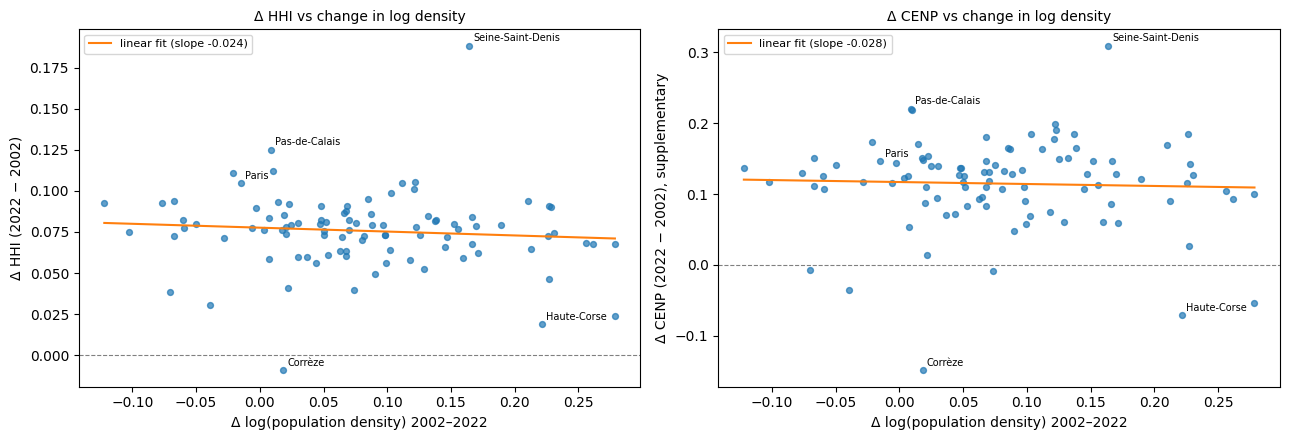

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (y, label) in zip(axes, [("delta_HHI", "Δ HHI (2022 − 2002)"), ("delta_CENP", "Δ CENP (2022 − 2002), supplementary")]):
    department_scatter(wide, "delta_log_density", y, ax, f"{label.split(' (')[0]} vs change in log density",
                       "Δ log(population density) 2002–2022", label)
    ax.axhline(0, color="grey", lw=0.8, ls="--")
show_plot(fig)

In [11]:
def delta_association(y, x="delta_log_density"):
    pearson = stats.pearsonr(wide[y], wide[x])
    spearman = stats.spearmanr(wide[y], wide[x])
    ols = smf.ols(f"{y} ~ {x}", data=wide).fit()
    robust = ols.get_robustcov_results(cov_type="HC1")
    return pd.Series({
        "n": int(ols.nobs),
        "pearson_r": pearson.statistic, "pearson_p": pearson.pvalue,
        "spearman_rho": spearman.statistic, "spearman_p": spearman.pvalue,
        f"ols_coef_{x}": ols.params[x], "ols_se": ols.bse[x], "ols_p": ols.pvalues[x],
        "ols_se_HC1": robust.bse[1], "ols_p_HC1": robust.pvalues[1], "ols_R2": ols.rsquared,
    }, name=f"{y} ~ {x}")


pd.concat([delta_association("delta_HHI"), delta_association("delta_CENP")], axis=1)

,delta_HHI ~ delta_log_density,delta_CENP ~ delta_log_density
n,96.000000,96.000000
pearson_r,-0.091532,-0.039650
pearson_p,0.375112,0.701312
spearman_rho,-0.158790,-0.041129
spearman_p,0.122284,0.690729
ols_coef_delta_log_density,-0.023612,-0.027727
ols_se,0.026495,0.072071
ols_p,0.375112,0.701312
ols_se_HC1,0.028152,0.081289
ols_p_HC1,0.403761,0.733791


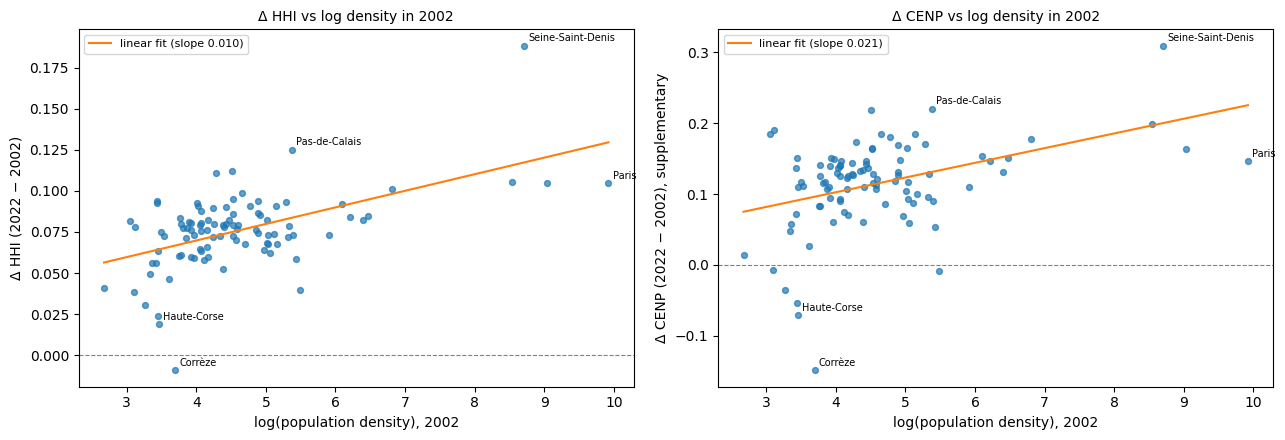

,delta_HHI ~ log_density_2002,delta_CENP ~ log_density_2002
n,9.600000e+01,96.000000
pearson_r,5.376218e-01,0.407815
pearson_p,1.621974e-08,0.000037
spearman_rho,4.072708e-01,0.335241
spearman_p,3.819028e-05,0.000841
ols_coef_log_density_2002,1.008247e-02,0.020733
ols_se,1.630984e-03,0.004788
ols_p,1.621974e-08,0.000037
ols_se_HC1,2.571456e-03,0.005847
ols_p_HC1,1.675406e-04,0.000612


In [12]:
# Is the 2002 level of density associated with the change in concentration?
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (y, label) in zip(axes, [("delta_HHI", "Δ HHI (2022 − 2002)"), ("delta_CENP", "Δ CENP (2022 − 2002), supplementary")]):
    department_scatter(wide, "log_density_2002", y, ax, f"{label.split(' (')[0]} vs log density in 2002",
                       "log(population density), 2002", label)
    ax.axhline(0, color="grey", lw=0.8, ls="--")
show_plot(fig)
pd.concat([delta_association("delta_HHI", "log_density_2002"), delta_association("delta_CENP", "log_density_2002")],
          axis=1)

## 4. Secondary cliff measures

* `cliff_magnitude`: size of the largest drop between consecutive ranked vote shares;
* `cliff_ratio`: how much that drop stands out from the other gaps (0.5–1).

`cliff_location` is ordinal, so it is only described by its distribution across density quartiles, with a
Spearman rank correlation as a summary — no linear regression.

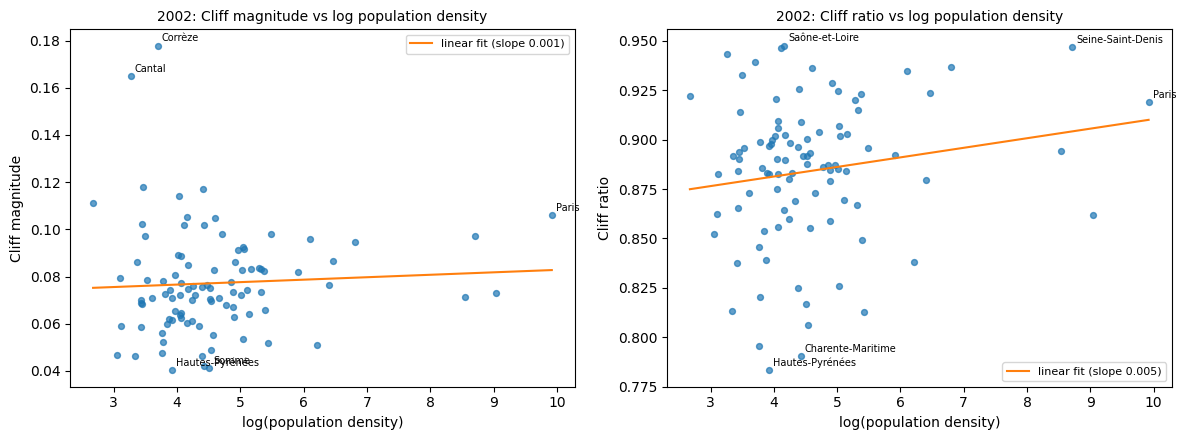

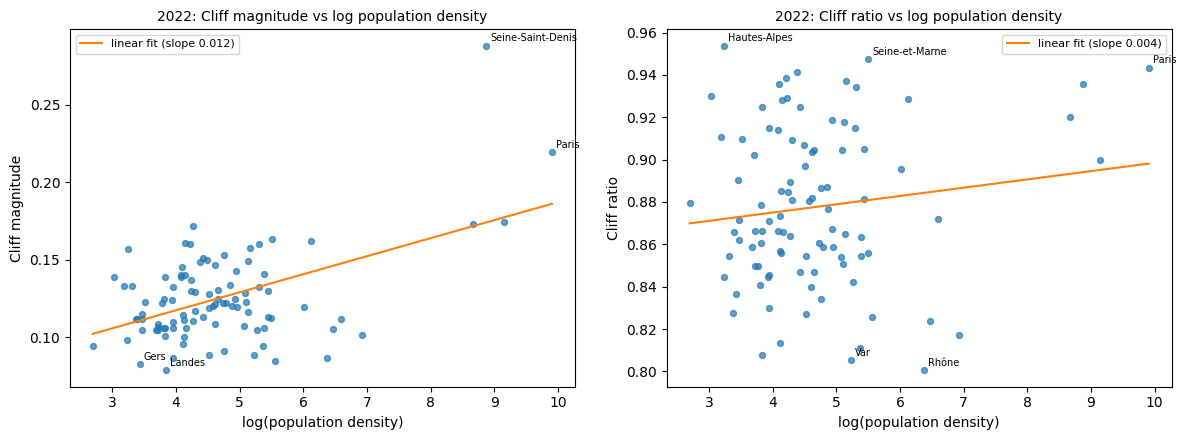

2002                                                 2022                                          
                    HHI       CENP cliff_magnitude cliff_ratio           HHI          CENP cliff_magnitude cliff_ratio
n             96.000000  96.000000       96.000000   96.000000  9.600000e+01  9.600000e+01    9.600000e+01   96.000000
pearson_r     -0.023563   0.006686        0.056996    0.164001  5.900161e-01  5.724848e-01    4.953326e-01    0.131128
pearson_p      0.819741   0.948455        0.581235    0.110343  2.518639e-10  1.101295e-09    2.885914e-07    0.202853
spearman_rho  -0.033207  -0.033207        0.139799    0.144235  4.569045e-01  4.569045e-01    2.140125e-01    0.059075
spearman_p     0.748070   0.748070        0.174310    0.160904  2.878042e-06  2.878042e-06    3.628306e-02    0.567504
ols_coef      -0.000197   0.000235        0.001039    0.004844  9.369958e-03  1.980751e-02    1.163883e-02    0.003914
ols_se         0.000862   0.003632        0.001876    0.003005  1.322495e-03  2.925978e-03    2.105329e-03    0.003052
ols_se_HC1     0.000877   0.003759        0.001810    0.002792  2.156503e-03  3.335698e-03    3.826756e-03    0.003250
ols_p          0.819741   0.948455        0.581235    0.110343  2.518639e-10  1.101295e-09    2.885914e-07    0.202853
ols_p_HC1      0.822840   0.950185        0.567477    0.086002  3.520133e-05  4.820769e-08    3.051271e-03    0.231435
ols_R2         0.000555   0.000045        0.003249    0.026896  3.481190e-01  3.277389e-01    2.453544e-01    0.017195

In [13]:
SECONDARY = {"cliff_magnitude": "Cliff magnitude", "cliff_ratio": "Cliff ratio"}

for year in YEARS:
    sub = main[main["year"] == year]
    fig, axes = plt.subplots(1, len(SECONDARY), figsize=(12, 4.5))
    for ax, (var, label) in zip(axes, SECONDARY.items()):
        department_scatter(sub, "log_density", var, ax, f"{year}: {label} vs log population density",
                           "log(population density)", label)
    show_plot(fig)

pd.concat({year: pd.DataFrame({var: association_stats(main[main["year"] == year], var)
                               for var in ["HHI", "CENP", *SECONDARY]})
           for year in YEARS}, axis=1)

In [14]:
# cliff_location: distribution (share of départements) by density quartile, within each year
for year in YEARS:
    sub = main[main["year"] == year]
    print(f"\n{year} — cliff_location by density quartile (row shares; n in last column)")
    table = pd.crosstab(sub["density_quartile"], sub["cliff_location"], normalize="index").round(2)
    table["n"] = sub.groupby("density_quartile").size()
    display(table)
    rho = stats.spearmanr(sub["cliff_location"], sub["density"])
    print(f"Spearman rho(cliff_location, density) = {rho.statistic:.3f} (p = {rho.pvalue:.3f})")


2002 — cliff_location by density quartile (row shares; n in last column)


cliff_location,1,2,3,4,n
density_quartile,,,,,
Q1 (least dense),0.33,0.21,0.46,0.00,24
Q2,0.04,0.17,0.79,0.00,24
Q3,0.25,0.21,0.50,0.04,24
Q4 (most dense),0.08,0.29,0.62,0.00,24


Spearman rho(cliff_location, density) = 0.118 (p = 0.251)

2022 — cliff_location by density quartile (row shares; n in last column)


cliff_location,1,2,3,n
density_quartile,,,,
Q1 (least dense),0.17,0.17,0.67,24
Q2,0.12,0.12,0.75,24
Q3,0.21,0.00,0.79,24
Q4 (most dense),0.12,0.29,0.58,24


Spearman rho(cliff_location, density) = -0.055 (p = 0.591)
